In [504]:
from IPython.display import Markdown as md

In [505]:
import pandas as pd
import numpy as np
from utils import (
    convert_to_numeric,
    split_dict_columns,
    get_tot_results_compare,
    compare_unique_solved_instances,
    build_markdown_comparison_matrix,
    copy_instances,
    plot_performance_profiles,
    plot_time_histogram,
    query_time,
    SolverResult,
    SOPLEX,
    GLPK,
    QSOPTEX,
)

In [506]:
DROP_UNSOLVED = True

In [507]:
all_instances = pd.read_csv("../instances.csv").set_index("file")
all_instances

""
file
0003-labyrinth-11-0.smt2
0011-labyrinth-12-0.smt2
0018-labyrinth-11-0.smt2
0028-labyrinth-12-0.smt2
0036-labyrinth-17-0.smt2
...
yPositive-SIscaled75.bpl_Iteration1_Loop_3-pieceTemplate.smt2
yPositive-SIscaled75.bpl_Iteration1_Loop_4-phaseTemplate.smt2
yPositive-SIscaled75.bpl_Iteration1_Loop_4-pieceTemplate.smt2


In [508]:
soplex_i100 = pd.read_csv("../soplex_i100.csv").set_index("file")
soplex_i100 = soplex_i100[soplex_i100["resultS"].isin(["sat", "unsat"])] if DROP_UNSOLVED else soplex_i100
soplex_i100

,options::pivots,options::checkModels,build,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,...,theory::arith::z::arith::relax::calls,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,options::strict,resultS,timeS
file,,,,,,,,,,,,,,,,,,,,,
sin-problem-7-weak-chunk-0022.smt2,100,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,30ms,...,0,0,0,0,0,0,0,0,sat,0.030
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_7-phaseTemplate.smt2,100,0,production,0,0,67278,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Brave...,1062264ms,...,180,0,0,126,54,54,0,0,unsat,1062.264
constraints-cooking12.smt2,100,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,56ms,...,0,0,0,0,0,0,0,0,sat,0.056
sc-13.induction3.cvc.smt2,100,0,production,1,1,3249,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-13...,247ms,...,0,0,0,0,0,0,0,0,sat,0.247
sc-6.induction.cvc.smt2,100,0,production,1,1,470,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-6....,69ms,...,0,0,0,0,0,0,0,0,sat,0.069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Chua-2-IL-L-chunk-0066.smt2,100,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Chua-...,44ms,...,0,0,0,0,0,0,0,0,sat,0.044
19.smt2,100,0,production,1,1,120,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/19.smt2,80ms,...,0,0,0,0,0,0,0,0,sat,0.080
_overflow1.i_3_8_2.bpl_11.smt2,100,0,production,0,0,2558290,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/_over...,6088207ms,...,105,0,0,70,35,0,0,0,unsat,6088.207


In [509]:
soplex_i10 = pd.read_csv("../soplex_i10.csv").set_index("file")
soplex_i10 = soplex_i10[soplex_i10["resultS"].isin(["sat", "unsat"])] if DROP_UNSOLVED else soplex_i10
soplex_i10

,options::pivots,options::checkModels,build,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,...,theory::arith::z::approx::refinements,theory::arith::z::arith::relax::calls,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,resultS,timeS
file,,,,,,,,,,,,,,,,,,,,,
sin-problem-7-weak-chunk-0022.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,38ms,...,NaN,0,0,0,0,0,0,0,sat,0.038
constraints-cooking12.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,55ms,...,{ 0: 1 },1,0,0,1,0,0,0,sat,0.055
sc-13.induction3.cvc.smt2,10,0,production,1,1,3249,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-13...,201ms,...,NaN,0,0,0,0,0,0,0,sat,0.201
sin-problem-7-weak-chunk-0007.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,30ms,...,NaN,0,0,0,0,0,0,0,sat,0.030
sin-problem-7-weak-chunk-0095.smt2,10,0,production,0,0,0,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,37ms,...,NaN,0,0,0,0,0,0,0,unsat,0.037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
sc-23.base.cvc.smt2,10,0,production,0,0,69061,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-23...,2255511ms,...,"{ 0: 16, 1: 1127, 2: 31095, 3: 6201, 4: 2392, ...",41573,0,0,1172,40401,40393,0,unsat,2255.511
sin-problem-7-chunk-0006.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,37ms,...,NaN,0,0,0,0,0,0,0,sat,0.037
Chua-2-IL-L-chunk-0066.smt2,10,0,production,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Chua-...,45ms,...,NaN,0,0,0,0,0,0,0,sat,0.045


In [510]:
soplex_i200 = pd.read_csv("../soplex_i200.csv").set_index("file")
soplex_i200 = soplex_i200[soplex_i200["resultS"].isin(["sat", "unsat"])] if DROP_UNSOLVED else soplex_i200
soplex_i200

,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,preprocessing::theory-preprocess,sat::clauses_literals,sat::conflicts,...,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,options::pivots,options::checkModels,options::strict,resultS,timeS
file,,,,,,,,,,,,,,,,,,,,,
sin-problem-7-weak-chunk-0022.smt2,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,33ms,0ms,0,0,...,0,0,0,0,0,200,0,0,sat,0.033
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_7-phaseTemplate.smt2,0,0,87590,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Brave...,828966ms,43ms,4336530,26859,...,0,14,3,3,0,200,0,0,unsat,828.966
constraints-cooking12.smt2,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,40ms,0ms,0,0,...,0,0,0,0,0,200,0,0,sat,0.040
sc-13.induction3.cvc.smt2,1,1,3249,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-13...,234ms,11ms,13160,77,...,0,0,0,0,0,200,0,0,sat,0.234
sas2.t2.c_Iteration3_Lasso_6-phaseTemplate.smt2,1,1,181030,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sas2....,23508ms,330ms,371988,404,...,0,0,0,0,0,200,0,0,sat,23.508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Chua-2-IL-L-chunk-0066.smt2,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Chua-...,44ms,0ms,0,0,...,0,0,0,0,0,200,0,0,sat,0.044
19.smt2,1,1,120,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/19.smt2,105ms,1ms,2375,39,...,0,0,0,0,0,200,0,0,sat,0.105
_overflow1.i_3_8_2.bpl_11.smt2,0,0,3023801,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/_over...,11032821ms,7ms,22681419,2219181,...,0,1,0,0,0,200,0,0,unsat,11032.821


In [511]:
soplex_i200_strict = pd.read_csv("../soplex_i200_strict.csv").set_index("file")
soplex_i200_strict = soplex_i200_strict[soplex_i200_strict["resultS"].isin(["sat", "unsat"])] if DROP_UNSOLVED else soplex_i200_strict
soplex_i200_strict

,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,preprocessing::theory-preprocess,sat::clauses_literals,sat::conflicts,...,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,options::pivots,options::checkModels,options::strict,resultS,timeS
file,,,,,,,,,,,,,,,,,,,,,
sin-problem-7-weak-chunk-0022.smt2,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sin-p...,33ms,0ms,0,0,...,0,0,0,0,0,200,0,0,sat,0.033
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_7-phaseTemplate.smt2,0,0,87874,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Brave...,874447ms,46ms,3791887,26027,...,0,35,8,0,0,200,0,1,unsat,874.447
constraints-cooking12.smt2,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,40ms,0ms,0,0,...,0,0,0,0,0,200,0,0,sat,0.040
sc-13.induction3.cvc.smt2,1,1,3249,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sc-13...,234ms,11ms,13160,77,...,0,0,0,0,0,200,0,0,sat,0.234
sas2.t2.c_Iteration3_Lasso_6-phaseTemplate.smt2,1,1,181030,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/sas2....,23508ms,330ms,371988,404,...,0,0,0,0,0,200,0,0,sat,23.508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Chua-2-IL-L-chunk-0066.smt2,1,1,1,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Chua-...,44ms,0ms,0,0,...,0,0,0,0,0,200,0,0,sat,0.044
19.smt2,1,1,120,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/19.smt2,105ms,1ms,2375,39,...,0,0,0,0,0,200,0,0,sat,0.105
_overflow1.i_3_8_2.bpl_11.smt2,0,0,2569365,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/_over...,5350519ms,5ms,19060995,1892540,...,0,1,0,0,0,200,0,1,unsat,5350.519


In [512]:
def sanitize(df: pd.DataFrame):
    for col in df.columns:
        df[col] = df[col].apply(convert_to_numeric)

    df["theory::arith::z::approx::externalSimplexType"] = df["theory::arith::z::approx::externalSimplexType"].astype("category")
    precision_df = df["theory::arith::z::approx::precision"].apply(lambda x: split_dict_columns(x, "precision"))
    refinements = df["theory::arith::z::approx::refinements"].apply(lambda x: split_dict_columns(x, "refinements"))
    return pd.concat([df, precision_df, refinements], axis=1)

soplex_i10 = sanitize(soplex_i10)
soplex_i100 = sanitize(soplex_i100)
soplex_i200 = sanitize(soplex_i200)
soplex_i200_strict = sanitize(soplex_i200_strict)

In [513]:
# All instances with at least a call to the external simplex should have a value for the external simplex type
def check_external_simplex_calls(df: pd.DataFrame):
    assert len(df[(df["theory::arith::z::arith::relax::calls"] > 0) & (df["theory::arith::z::approx::externalSimplexType"].isna())]) == 0
    assert len(df[df["theory::arith::z::approx::externalSimplexType"].notna()]) == len(df[(df["theory::arith::z::arith::relax::calls"] > 0)])
    assert all(df[df["theory::arith::z::approx::externalSimplexType"].notna()]["theory::arith::z::approx::externalSimplexType"] == SOPLEX)
check_external_simplex_calls(soplex_i10)
check_external_simplex_calls(soplex_i100)
check_external_simplex_calls(soplex_i200)
check_external_simplex_calls(soplex_i200_strict)

In [514]:

INTERESTING_COLS = [
    "global::totalTime",
    "theory::arith::z::arith::relax::calls",
    "theory::arith::z::approx::lp::setup::timer",
    "theory::arith::z::approx::lp::timer",
    "theory::arith::z::arith::relax::feasible::failures",
    "theory::arith::z::arith::relax::infeasible::failures",
    "theory::arith::z::approx::precision",
    "theory::arith::z::approx::refinements",
    "theory::arith::attempt::extendedSearch",
    "resultS"
]

In [515]:
soplex_i10.loc["ecoliMILPglycerolYices3-60000.smt2"][INTERESTING_COLS]

global::totalTime                                            12967
theory::arith::z::arith::relax::calls                           49
theory::arith::z::approx::lp::setup::timer                     811
theory::arith::z::approx::lp::timer                           4627
theory::arith::z::arith::relax::feasible::failures               0
theory::arith::z::arith::relax::infeasible::failures             0
theory::arith::z::approx::precision                     { 64: 49 }
theory::arith::z::approx::refinements                    { 2: 49 }
theory::arith::attempt::extendedSearch                          12
resultS                                                        sat
Name: ecoliMILPglycerolYices3-60000.smt2, dtype: object

In [516]:
soplex_i100.loc["ecoliMILPglycerolYices3-60000.smt2"][INTERESTING_COLS]

global::totalTime                                            18419
theory::arith::z::arith::relax::calls                           41
theory::arith::z::approx::lp::setup::timer                     678
theory::arith::z::approx::lp::timer                           3787
theory::arith::z::arith::relax::feasible::failures               0
theory::arith::z::arith::relax::infeasible::failures             1
theory::arith::z::approx::precision                     { 64: 41 }
theory::arith::z::approx::refinements                    { 2: 41 }
theory::arith::attempt::extendedSearch                           9
resultS                                                        sat
Name: ecoliMILPglycerolYices3-60000.smt2, dtype: object

In [517]:
soplex_i200.loc["ecoliMILPglycerolYices3-60000.smt2"][INTERESTING_COLS]

global::totalTime                                            47994
theory::arith::z::arith::relax::calls                           48
theory::arith::z::approx::lp::setup::timer                     902
theory::arith::z::approx::lp::timer                           2463
theory::arith::z::arith::relax::feasible::failures               0
theory::arith::z::arith::relax::infeasible::failures             0
theory::arith::z::approx::precision                     { 64: 48 }
theory::arith::z::approx::refinements                    { 2: 48 }
theory::arith::attempt::extendedSearch                          12
resultS                                                        sat
Name: ecoliMILPglycerolYices3-60000.smt2, dtype: object

# Benchmarks

We are using the [SMT-LIB](https://smt-lib.org/benchmarks.shtml) benchmarks for our evaluation.

To be precise, we are using the [QF_LRA](https://smt-lib.org/logics-all.shtml#QF_LRA) theory benchmarks from the [SMT-LIB release 2025 of non-incremental benchmarks](https://zenodo.org/records/16740866).
The set is composed of 1753 instances.
We ran with a timeout of 6 hours (?) and a memory limit of 4GB.
We used the Comet HPC cluster from Newcastle University.
Each node uses an AMD EPYC 9745 @ 2.4 GHz 128-core processor (256 threads), although we only used one core per instance.

### Hardware details

| CPU           | Architecture | Frequency | Turbo frequency | Cores | Memory | L1      | L2        | L3     | Time limit |
| ------------- | ------------ | --------- | --------------- | ----- | ------ | ------- | --------- | ------ | ---------- |
| AMD EPYC 9745 | x86_64       | 2.4 GHz   | 3.7 GHz         | 1     | 4GB    | 6144 KB | 131072 KB | 256 MB | 6 hours    |

In [518]:
# Number of instances solved in total
def get_tot_results(df: pd.DataFrame) -> int:
    assert len(df["options::pivots"].unique()) > 0
    tot = 1753
    table_entries_by_pivot = []
    for pivots in df["options::pivots"].unique():
        sub_df = df[df["options::pivots"] == pivots]
        solved = len(sub_df)
        not_external = len(sub_df[sub_df["theory::arith::z::arith::relax::calls"] == 0])
        external = len(sub_df[sub_df["theory::arith::z::arith::relax::calls"] > 0])
        assert solved == not_external + external
        entry =  f"| **QF_LRA** | {pivots}             | {tot}               | {solved}         | {tot - solved}     | {external}                            | {not_external}                           | 0      |"
        table_entries_by_pivot.append(entry)
        table_rows = "\n".join(table_entries_by_pivot)
    return f"""
### Benchmarks details
    
| Theory     | Rational pivot limit | Number of instances | Solved instances | Unsolved instances | Instances with external simplex calls | Instances without external simplex calls | Errors |
| ---------- | -------------------- | ------------------- | ---------------- | ------------------ | ------------------------------------- | ---------------------------------------- | ------ |
{table_rows}
"""
md(get_tot_results(pd.concat([soplex_i10, soplex_i100, soplex_i200, soplex_i200_strict])))


### Benchmarks details

| Theory     | Rational pivot limit | Number of instances | Solved instances | Unsolved instances | Instances with external simplex calls | Instances without external simplex calls | Errors |
| ---------- | -------------------- | ------------------- | ---------------- | ------------------ | ------------------------------------- | ---------------------------------------- | ------ |
| **QF_LRA** | 10             | 1753               | 1111         | 642     | 467                            | 644                           | 0      |
| **QF_LRA** | 100             | 1753               | 1580         | 173     | 208                            | 1372                           | 0      |
| **QF_LRA** | 200             | 1753               | 3382         | -1629     | 252                            | 3130                           | 0      |


In [519]:
solver_inputs = [
    SolverResult(soplex_i10, "SoPlex (10 pivots)", "S"),
    SolverResult(soplex_i100, "SoPlex (100 pivots)", "S"),
    SolverResult(soplex_i200, "SoPlex (200 pivots)", "S"),
    SolverResult(soplex_i200_strict, "SoPlex (200 pivots, strict)", "S"),
]

pairwise_only = compare_unique_solved_instances(*solver_inputs)
solver_order = [solver.solver_name for solver in solver_inputs]

md(build_markdown_comparison_matrix(pairwise_only, solver_order))

### Pairwise matrix (instances solved by row solver but not by column solver)
| Solver A \ Solver B | SoPlex (10 pivots) | SoPlex (100 pivots) | SoPlex (200 pivots) | SoPlex (200 pivots, strict) |
| --- | --- | --- | --- | --- |
| SoPlex (10 pivots) |  | 10 | 1 | 15 |
| SoPlex (100 pivots) | 479 |  | 0 | 19 |
| SoPlex (200 pivots) | 578 | 108 |  | 22 |
| SoPlex (200 pivots, strict) | 598 | 133 | 28 |  |

In [520]:
merged = pd.merge(soplex_i10, soplex_i100, left_index=True, right_index=True, suffixes=("_i10", "_i100"))
merged = merged[["global::totalTime_i10", "global::totalTime_i100"]]
merged

,global::totalTime_i10,global::totalTime_i100
file,,
sin-problem-7-weak-chunk-0022.smt2,38,30
constraints-cooking12.smt2,55,56
sc-13.induction3.cvc.smt2,201,247
sin-problem-7-weak-chunk-0007.smt2,30,25
sin-problem-7-weak-chunk-0095.smt2,37,28
...,...,...
sc-23.base.cvc.smt2,2255511,11552
sin-problem-7-chunk-0006.smt2,37,34
Chua-2-IL-L-chunk-0066.smt2,45,44


In [521]:
external = soplex_i100[soplex_i100["theory::arith::z::arith::relax::calls"] > 0]
external.sort_values("global::totalTime", inplace=True)
external[["global::totalTime", "theory::arith::z::arith::relax::calls", "theory::arith::z::approx::externalSimplexType","resultS"]].head(20)

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::externalSimplexType,resultS
file,,,,
constraints-cooking13.smt2,54,1,2.0,sat
constraints-cooking19.smt2,55,1,2.0,sat
constraints-cooking20.smt2,60,1,2.0,sat
constraints-cooking16.smt2,60,1,2.0,sat
constraints-cooking14.smt2,63,1,2.0,sat
constraints-tms-2-3-light-30.smt2,67,1,2.0,sat
constraints-tms-2-3-light-20.smt2,70,1,2.0,sat
constraints-cooking21.smt2,70,1,2.0,sat
constraints-tempo-depth-30.smt2,78,1,2.0,sat


### Comparison with other solvers

We aim to compare our implementation with other state-of-the-art SMT solvers, such as [Z3](https://github.com/Z3Prover/z3) and [Yices](https://yices.csl.sri.com/), as well as the baseline version of [cvc5](https://cvc5.github.io/), using both the rational simplex implementation and the approximate one via [GLPK](https://www.gnu.org/software/glpk/).

In [522]:
yices = pd.read_csv("../yices.csv").dropna(subset=["resultY"]).set_index("file")
# Drop rows where the result is not SAT or UNSAT (i.e. where the solver did not solve the instance)
yices = yices[yices["resultY"].isin(["sat", "unsat"])] if DROP_UNSOLVED else yices
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(yices, "Yices", "Y")))


#### Yices comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | Yices only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1724         | 29       | 0 | 1571    | 9 | 153 |


In [523]:
z3 = pd.read_csv("../z3.csv").dropna(subset=["resultZ"]).set_index("file")
z3 = z3[z3["resultZ"].isin(["sat", "unsat"])] if DROP_UNSOLVED else z3
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(z3, "Z3", "Z")))


#### Z3 comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | Z3 only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1691         | 62       | 0 | 1555    | 25 | 136 |


In [524]:
cvc5 = pd.read_csv("../cvc5.csv").dropna(subset=["resultC"]).set_index("file")
cvc5 = cvc5[cvc5["resultC"].isin(["sat", "unsat"])] if DROP_UNSOLVED else cvc5
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(cvc5, "cvc5", "C")))


#### cvc5 comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | cvc5 only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1713         | 40       | 0 | 1570    | 10 | 143 |


In [525]:
glpk = pd.read_csv("../glpk_i200.csv").dropna(subset=["resultG"]).set_index("file")
glpk = glpk[glpk["resultG"].isin(["sat", "unsat"])] if DROP_UNSOLVED else glpk
md(get_tot_results_compare(SolverResult(soplex_i100, "SoPlex", "S"), SolverResult(glpk, "GLPK", "G")))


#### GLPK comparison with SoPlex

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | SoPlex only     | GLPK only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1678         | 75       | 0 | 1578    | 2 | 100 |


In [526]:
glpk[glpk["theory::arith::z::arith::relax::calls"] > 0]

,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,preprocessing::theory-preprocess,sat::clauses_literals,sat::conflicts,...,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,options::pivots,options::checkModels,resultG,timeG
file,,,,,,,,,,,,,,,,,,,,,
constraints-temporal-machine-shop-2-3-A40.smt2,1,1,657,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,204ms,4ms,2788,0,...,0,0,1,0,0,0,NaN,NaN,sat,0.204
constraints-tempo-matrix7x7.pddl.smt2,1,1,30757,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,762ms,20ms,6656,0,...,0,0,1,0,0,0,NaN,NaN,sat,0.762
constraints-temporal-machine-shop-2-3-A60.smt2,1,1,2152,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,322ms,12ms,5536,0,...,0,0,1,0,0,0,NaN,NaN,sat,0.322
janne_complex.t2.c_Iteration3_Lasso_4-pieceTemplate.smt2,0,0,582680,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/janne...,1047392ms,285ms,1866056,22634,...,0,3,3,0,0,0,200.0,0.0,unsat,1047.392
ecoliMILPglycerolYices3-100000.smt2,1,1,65,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/ecoli...,16984ms,59ms,856,0,...,0,0,7,6,0,0,200.0,0.0,sat,16.984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
danoint-50.smt2,0,0,132,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/danoi...,329ms,44ms,15498,8,...,0,0,2,0,0,0,NaN,NaN,unsat,0.329
eric.t2.c_Iteration1_Lasso_3-pieceTemplate.smt2,1,1,388512,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/eric....,600482ms,162ms,1249370,16328,...,0,1,1,0,0,0,NaN,NaN,sat,600.482
toeplz.t2.c_Iteration2_Loop_4-pieceTemplate.smt2,1,1,657476,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/toepl...,6880820ms,364ms,709487,2391,...,0,10581,10581,0,0,0,200.0,0.0,sat,6880.820


In [527]:
df = soplex_i200
assert all(df["theory::arith::z::arith::relax::other"] == 0), "Expected no errors in other category"

called = df[df["theory::arith::z::arith::relax::calls"] > 0][INTERESTING_COLS]
called.sort_values("theory::arith::z::arith::relax::calls", inplace=True)
called

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::precision,theory::arith::z::approx::refinements,theory::arith::attempt::extendedSearch,resultS
file,,,,,,,,,,
constraints-tempo-depth-100.smt2,153,1,4,28,0,0,{ 64: 1 },{ 1: 1 },0,sat
constraints-tempo-width-50.smt2,10836,1,25,61,0,0,{ 64: 1 },{ 1: 1 },1,sat
ecoliFBAyicesTest-875.smt2,568,1,12,33,0,0,{ 64: 1 },{ 2: 1 },0,sat
sas2.t2.c_Iteration6_Lasso_4-pieceTemplate.smt2,1060544,1,83,216,0,0,{ 64: 1 },{ 2: 1 },1,sat
GulwaniJainKoskinen-2009PLDI-Fig1_true-termination.c_Iteration1_Lasso_7-phaseTemplate.smt2,5651825,1,840,2361,0,0,{ 64: 1 },{ 2: 1 },1,unsat
...,...,...,...,...,...,...,...,...,...,...
simple-scaled250.bpl_Iteration1_Lasso_5-nestedTemplate.smt2,6695489,3740,812618,4539681,0,3715,"{ 167: 3735, 64: 5 }","{ 1: 5, 2: 3727, 4: 8 }",3740,sat
simple-scaled200.bpl_Iteration1_Lasso_5-nestedTemplate.smt2,9775405,4279,1078002,6820197,0,4263,"{ 167: 4275, 64: 4 }","{ 1: 4, 2: 4268, 3: 4, 4: 3 }",4279,sat
yPositive-SIscaled50.bpl_Iteration1_Loop_4-pieceTemplate.smt2,10292571,5920,757358,5301265,0,5910,"{ 167: 5912, 64: 8 }","{ 1: 3, 2: 2253, 3: 1147, 4: 2515, 5: 1, 6: 1 }",5920,unsat


In [528]:
called[called["theory::arith::z::arith::relax::feasible::failures"] > 0][INTERESTING_COLS]

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::precision,theory::arith::z::approx::refinements,theory::arith::attempt::extendedSearch,resultS
file,,,,,,,,,,
BradleyMannaSipma-2005ICALP-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2,3938049,17,3809,28555,1,3,"{ 167: 13, 250: 2, 64: 2 }","{ 1: 1, 2: 1, 3: 3, 4: 5, 5: 1, 7: 4, 9: 2 }",17,unsat


In [529]:
soplex_i10.loc["ecoliMILPglycerolYices3-60000.smt2"][INTERESTING_COLS + ["build"]]

global::totalTime                                            12967
theory::arith::z::arith::relax::calls                           49
theory::arith::z::approx::lp::setup::timer                     811
theory::arith::z::approx::lp::timer                           4627
theory::arith::z::arith::relax::feasible::failures               0
theory::arith::z::arith::relax::infeasible::failures             0
theory::arith::z::approx::precision                     { 64: 49 }
theory::arith::z::approx::refinements                    { 2: 49 }
theory::arith::attempt::extendedSearch                          12
resultS                                                        sat
build                                                   production
Name: ecoliMILPglycerolYices3-60000.smt2, dtype: object

In [530]:
soplex_i100.loc["ecoliMILPglycerolYices3-60000.smt2"][INTERESTING_COLS]

global::totalTime                                            18419
theory::arith::z::arith::relax::calls                           41
theory::arith::z::approx::lp::setup::timer                     678
theory::arith::z::approx::lp::timer                           3787
theory::arith::z::arith::relax::feasible::failures               0
theory::arith::z::arith::relax::infeasible::failures             1
theory::arith::z::approx::precision                     { 64: 41 }
theory::arith::z::approx::refinements                    { 2: 41 }
theory::arith::attempt::extendedSearch                           9
resultS                                                        sat
Name: ecoliMILPglycerolYices3-60000.smt2, dtype: object

In [531]:
soplex_i200.loc["ecoliMILPglycerolYices3-60000.smt2"][INTERESTING_COLS]

global::totalTime                                            47994
theory::arith::z::arith::relax::calls                           48
theory::arith::z::approx::lp::setup::timer                     902
theory::arith::z::approx::lp::timer                           2463
theory::arith::z::arith::relax::feasible::failures               0
theory::arith::z::arith::relax::infeasible::failures             0
theory::arith::z::approx::precision                     { 64: 48 }
theory::arith::z::approx::refinements                    { 2: 48 }
theory::arith::attempt::extendedSearch                          12
resultS                                                        sat
Name: ecoliMILPglycerolYices3-60000.smt2, dtype: object

In [532]:
temp_df = soplex_i100
temp_df[(temp_df["theory::arith::z::arith::relax::infeasible::failures"] > 0)][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::precision,theory::arith::z::approx::refinements,theory::arith::attempt::extendedSearch,resultS
file,,,,,,,,,,
ecoliMILPglycerolYices3-60000.smt2,18419,41,678,3787,0,1,{ 64: 41 },{ 2: 41 },9,sat
ecoliMILPglycerolYices3-90000.smt2,20317,54,883,4585,0,2,{ 64: 54 },{ 2: 54 },11,sat
ecoliMILPglycerolYices3-70000.smt2,22382,48,781,4173,0,2,{ 64: 48 },{ 2: 48 },12,sat
ecoliMILPglycerolYices3-50000.smt2,23794,43,708,4014,0,1,{ 64: 43 },{ 2: 43 },11,sat
ecoliMILPglycerolYices3-100000.smt2,23897,51,829,4193,0,2,{ 64: 51 },{ 2: 51 },12,sat
ecoliMILPglycerolYices3-80000.smt2,25212,46,753,4146,0,2,{ 64: 46 },{ 2: 46 },12,sat
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_6-phaseTemplate.smt2,91580,37,265,925,0,13,"{ 167: 13, 64: 24 }","{ 2: 4, 3: 20, 4: 13 }",33,unsat
Braverman-2006CAV-Ex1-int.bpl_Iteration1_Lasso_6-phaseTemplate.smt2,95016,37,271,986,0,13,"{ 167: 13, 64: 24 }","{ 2: 4, 3: 20, 4: 13 }",33,unsat
_standard_init7_ground.i_3_2_2.bpl_7.smt2,147979,6,55,424,0,4,"{ 167: 5, 64: 1 }","{ 4: 4, 5: 2 }",6,unsat


In [533]:
glpk[glpk["theory::arith::z::arith::relax::other"] != 0]

,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,preprocessing::theory-preprocess,sat::clauses_literals,sat::conflicts,...,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,options::pivots,options::checkModels,resultG,timeG
file,,,,,,,,,,,,,,,,,,,,,
BradleyMannaSipma-2005ICALP-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2,0,0,1831771,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/Bradl...,3699736ms,469ms,3587672,22686,...,0,209,209,0,0,1,200.0,0.0,unsat,3699.736


In [534]:
glpk[glpk["theory::arith::z::arith::relax::calls"] > 0]

,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,preprocessing::theory-preprocess,sat::clauses_literals,sat::conflicts,...,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,options::pivots,options::checkModels,resultG,timeG
file,,,,,,,,,,,,,,,,,,,,,
constraints-temporal-machine-shop-2-3-A40.smt2,1,1,657,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,204ms,4ms,2788,0,...,0,0,1,0,0,0,NaN,NaN,sat,0.204
constraints-tempo-matrix7x7.pddl.smt2,1,1,30757,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,762ms,20ms,6656,0,...,0,0,1,0,0,0,NaN,NaN,sat,0.762
constraints-temporal-machine-shop-2-3-A60.smt2,1,1,2152,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,322ms,12ms,5536,0,...,0,0,1,0,0,0,NaN,NaN,sat,0.322
janne_complex.t2.c_Iteration3_Lasso_4-pieceTemplate.smt2,0,0,582680,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/janne...,1047392ms,285ms,1866056,22634,...,0,3,3,0,0,0,200.0,0.0,unsat,1047.392
ecoliMILPglycerolYices3-100000.smt2,1,1,65,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/ecoli...,16984ms,59ms,856,0,...,0,0,7,6,0,0,200.0,0.0,sat,16.984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
danoint-50.smt2,0,0,132,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/danoi...,329ms,44ms,15498,8,...,0,0,2,0,0,0,NaN,NaN,unsat,0.329
eric.t2.c_Iteration1_Lasso_3-pieceTemplate.smt2,1,1,388512,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/eric....,600482ms,162ms,1249370,16328,...,0,1,1,0,0,0,NaN,NaN,sat,600.482
toeplz.t2.c_Iteration2_Loop_4-pieceTemplate.smt2,1,1,657476,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/toepl...,6880820ms,364ms,709487,2391,...,0,10581,10581,0,0,0,200.0,0.0,sat,6880.820


In [535]:
glpk[glpk["theory::arith::z::arith::relax::feasible::failures"] > 0][["global::totalTime", "theory::arith::z::arith::relax::feasible::failures", "theory::arith::z::arith::relax::calls","theory::arith::z::approx::lp::timer", "theory::arith::z::arith::relax::infeasible::failures"]]

,global::totalTime,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::infeasible::failures
file,,,,,
janne_complex.t2.c_Iteration3_Lasso_4-pieceTemplate.smt2,1047392ms,3,3,17ms,0
GulwaniJainKoskinen-2009PLDI-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2,4629977ms,31,31,110638ms,0
yPositive-SIscaled50.bpl_Iteration1_Loop_4-pieceTemplate.smt2,7324954ms,6649,6649,83981ms,0
constraints-tempo-depth-100.smt2,485ms,1,1,39ms,0
constraints-tms-2-3-light-60.smt2,202ms,1,1,24ms,0
Lobnya-Boolean-Reordered.bpl_Iteration1_Loop_7-phaseTemplate.smt2,305557ms,7,7,63ms,0
yPositive-SIscaled100.bpl_Iteration1_Loop_3-pieceTemplate.smt2,10151927ms,15616,15618,209331ms,0
ludcmp.c.i.ludcmp.pl.t2.fixed.t2.c_Iteration9_Loop_7-phaseTemplate.smt2,835286ms,3,3,143ms,0
KroeningSharyginaTsitovichWintersteiger-2010CAV-Fig1_true-termination.c_Iteration1_Lasso_3-pieceTemplate.smt2,474488ms,3,4,362ms,0


In [536]:
glpk[glpk["theory::arith::z::arith::relax::infeasible::failures"] > 0][["global::totalTime", "theory::arith::z::arith::relax::feasible::failures", "theory::arith::z::arith::relax::calls","theory::arith::z::approx::lp::timer", "theory::arith::z::arith::relax::infeasible::failures"]]

,global::totalTime,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::infeasible::failures
file,,,,,
danoint-166.smt2,842812ms,0,1139,22740ms,6


In [537]:
glpk.loc["danoint-166.smt2"]

TheoryEngine::Checks_Full                                                                               1
TheoryEngine::Checks_Last_Call                                                                          1
TheoryEngine::Checks_Standard                                                                        4734
TheoryEngine::combineTheoriesCalls                                                                      0
TheoryEngine::combineTheoriesTime                                                                     0ms
driver::filename                                        /nobackup/proj/comet_lfplpsmf/QF_LRA/all/danoi...
global::totalTime                                                                                842812ms
preprocessing::theory-preprocess                                                                     40ms
sat::clauses_literals                                                                              111628
sat::conflicts                                

In [540]:
glpk[glpk["theory::arith::z::arith::relax::calls"] > 0]

,TheoryEngine::Checks_Full,TheoryEngine::Checks_Last_Call,TheoryEngine::Checks_Standard,TheoryEngine::combineTheoriesCalls,TheoryEngine::combineTheoriesTime,driver::filename,global::totalTime,preprocessing::theory-preprocess,sat::clauses_literals,sat::conflicts,...,theory::arith::z::arith::relax::exhausted,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::feasible::res,theory::arith::z::arith::relax::infeasible,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::arith::relax::other,options::pivots,options::checkModels,resultG,timeG
file,,,,,,,,,,,,,,,,,,,,,
constraints-temporal-machine-shop-2-3-A40.smt2,1,1,657,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,204ms,4ms,2788,0,...,0,0,1,0,0,0,NaN,NaN,sat,0.204
constraints-tempo-matrix7x7.pddl.smt2,1,1,30757,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,762ms,20ms,6656,0,...,0,0,1,0,0,0,NaN,NaN,sat,0.762
constraints-temporal-machine-shop-2-3-A60.smt2,1,1,2152,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/const...,322ms,12ms,5536,0,...,0,0,1,0,0,0,NaN,NaN,sat,0.322
janne_complex.t2.c_Iteration3_Lasso_4-pieceTemplate.smt2,0,0,582680,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/janne...,1047392ms,285ms,1866056,22634,...,0,3,3,0,0,0,200.0,0.0,unsat,1047.392
ecoliMILPglycerolYices3-100000.smt2,1,1,65,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/ecoli...,16984ms,59ms,856,0,...,0,0,7,6,0,0,200.0,0.0,sat,16.984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
danoint-50.smt2,0,0,132,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/danoi...,329ms,44ms,15498,8,...,0,0,2,0,0,0,NaN,NaN,unsat,0.329
eric.t2.c_Iteration1_Lasso_3-pieceTemplate.smt2,1,1,388512,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/eric....,600482ms,162ms,1249370,16328,...,0,1,1,0,0,0,NaN,NaN,sat,600.482
toeplz.t2.c_Iteration2_Loop_4-pieceTemplate.smt2,1,1,657476,0,0ms,/nobackup/proj/comet_lfplpsmf/QF_LRA/all/toepl...,6880820ms,364ms,709487,2391,...,0,10581,10581,0,0,0,200.0,0.0,sat,6880.820


In [541]:
called = glpk[glpk["theory::arith::z::arith::relax::calls"] > 0][["global::totalTime", "theory::arith::z::arith::relax::feasible::failures", "theory::arith::z::arith::relax::calls","theory::arith::z::approx::lp::timer", "theory::arith::z::arith::relax::infeasible::failures"]]
called.sort_values("theory::arith::z::arith::relax::calls")
called[called["theory::arith::z::arith::relax::feasible::failures"] > 0]

,global::totalTime,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::infeasible::failures
file,,,,,
janne_complex.t2.c_Iteration3_Lasso_4-pieceTemplate.smt2,1047392ms,3,3,17ms,0
GulwaniJainKoskinen-2009PLDI-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2,4629977ms,31,31,110638ms,0
yPositive-SIscaled50.bpl_Iteration1_Loop_4-pieceTemplate.smt2,7324954ms,6649,6649,83981ms,0
constraints-tempo-depth-100.smt2,485ms,1,1,39ms,0
constraints-tms-2-3-light-60.smt2,202ms,1,1,24ms,0
Lobnya-Boolean-Reordered.bpl_Iteration1_Loop_7-phaseTemplate.smt2,305557ms,7,7,63ms,0
yPositive-SIscaled100.bpl_Iteration1_Loop_3-pieceTemplate.smt2,10151927ms,15616,15618,209331ms,0
ludcmp.c.i.ludcmp.pl.t2.fixed.t2.c_Iteration9_Loop_7-phaseTemplate.smt2,835286ms,3,3,143ms,0
KroeningSharyginaTsitovichWintersteiger-2010CAV-Fig1_true-termination.c_Iteration1_Lasso_3-pieceTemplate.smt2,474488ms,3,4,362ms,0


In [542]:
soplex_i100.loc["fun4.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2"][INTERESTING_COLS]

global::totalTime                                                                    1180785
theory::arith::z::arith::relax::calls                                                    953
theory::arith::z::approx::lp::setup::timer                                             31216
theory::arith::z::approx::lp::timer                                                   270057
theory::arith::z::arith::relax::feasible::failures                                         0
theory::arith::z::arith::relax::infeasible::failures                                     924
theory::arith::z::approx::precision                                     { 167: 925, 64: 28 }
theory::arith::z::approx::refinements                   { 1: 2, 2: 65, 3: 68, 4: 817, 6: 1 }
theory::arith::attempt::extendedSearch                                                   953
resultS                                                                                  sat
Name: fun4.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2, dtype: object

### Cumulative comparisons

Using the [Performance Profile](https://link.springer.com/article/10.1007/s101070100263) approach, we can compare the solvers based on their performance across all instances.

In [543]:
z3_profile = z3.reset_index()[["file", "timeZ", "resultZ"]].set_index("file")
cvc5_profile = cvc5.reset_index()[["file", "timeC", "resultC"]].set_index("file")
yices_profile = yices.reset_index()[["file", "timeY", "resultY"]].set_index("file")
glpk_profile = glpk.reset_index()[["file", "timeG", "resultG"]].set_index("file")
soplex_i10_profile = (
    soplex_i10.reset_index()[["file", "timeS", "resultS"]]
    .rename(columns={"timeS": "timeS10", "resultS": "resultS10"})
    .set_index("file")
)
soplex_i100_profile = (
    soplex_i100.reset_index()[["file", "timeS", "resultS"]]
    .rename(columns={"timeS": "timeS100", "resultS": "resultS100"})
    .set_index("file")
)
soplex_i200_profile = (
    soplex_i200.reset_index()[["file", "timeS", "resultS"]]
    .rename(columns={"timeS": "timeS200", "resultS": "resultS200"})
    .set_index("file")
)
soplex_i200_strict_profile = (
    soplex_i200_strict.reset_index()[["file", "timeS", "resultS"]]
    .rename(columns={"timeS": "timeS200S", "resultS": "resultS200S"})
    .set_index("file") 
)
# Get the set of instances where any of the SoPlex variants makes external simplex calls, and filter all profiles to only those instances
external_instances = list(
    set()
    # set(soplex_i10[soplex_i10["theory::arith::z::arith::relax::calls"] > 0].index)
    | set(soplex_i100[soplex_i100["theory::arith::z::arith::relax::calls"] > 0].index)
    | set(soplex_i200[soplex_i200["theory::arith::z::arith::relax::calls"] > 0].index)
    | set(soplex_i200_strict[soplex_i200_strict["theory::arith::z::arith::relax::calls"] > 0].index)
)
cvc5_variants_results = [
    SolverResult(cvc5_profile, "cvc5", "C"),
    SolverResult(glpk_profile, "glpk", "G"),
    SolverResult(soplex_i10_profile, "SoPlex (10 pivots)", "S10"),
    SolverResult(soplex_i100_profile, "SoPlex (100 pivots)", "S100"),
    SolverResult(soplex_i200_profile, "SoPlex (200 pivots)", "S200"),
    SolverResult(soplex_i200_strict_profile, "SoPlex (200 pivots, strict)", "S200S"),
]
profile_results = (
    *cvc5_variants_results,
    SolverResult(z3_profile, "Z3", "Z"),
    SolverResult(yices_profile, "yices", "Y"),
)
external_cvc5_variants__results = [
    SolverResult(cvc5_profile.loc[np.intersect1d(cvc5_profile.index, external_instances)], "cvc5", "C"),
    SolverResult(glpk_profile.loc[np.intersect1d(glpk_profile.index, external_instances)], "glpk", "G"),
    SolverResult(soplex_i10_profile.loc[np.intersect1d(soplex_i10_profile.index, external_instances)], "SoPlex (10 pivots)", "S10"),
    SolverResult(soplex_i100_profile.loc[np.intersect1d(soplex_i100_profile.index, external_instances)], "SoPlex (100 pivots)", "S100"),
    SolverResult(soplex_i200_profile.loc[np.intersect1d(soplex_i200_profile.index, external_instances)], "SoPlex (200 pivots)", "S200"),
    SolverResult(soplex_i200_strict_profile.loc[np.intersect1d(soplex_i200_strict_profile.index, external_instances)], "SoPlex (200 pivots, strict)", "S200S"),
]
external_profile_results = (
    *external_cvc5_variants__results,
    SolverResult(z3_profile.loc[np.intersect1d(z3_profile.index, external_instances)], "Z3", "Z"),
    SolverResult(yices_profile.loc[np.intersect1d(yices_profile.index, external_instances)], "yices", "Y"),
)

In [544]:
unsolved_yices = set(all_instances.loc[~all_instances.index.isin(yices_profile.index)].index)
unsolved_yices

{'0206-labyrinth-20-0.smt2',
 'BradleyMannaSipma-2005ICALP-Fig1_true-termination.c_Iteration1_Lasso_4-pieceTemplate.smt2',
 'Braverman-2006CAV-Ex1-int.bpl_Iteration1_Lasso_7-phaseTemplate.smt2',
 'Braverman-2006CAV-Ex1-int.bpl_Iteration1_Loop_7-phaseTemplate.smt2',
 'LeeJonesBen-Amram-2001POPL-Ex5_true-termination.c_Iteration2_Lasso_4-pieceTemplate.smt2',
 '_gj2007.c.i_4_3_3.bpl_11.smt2',
 '_overflow1.i_3_8_2.bpl_11.smt2',
 '_sanfoundry_10_ground.i_6_3_3.bpl_13.smt2',
 'constraint-413064.smt2',
 'constraint-556101.smt2',
 'danoint-65.smt2',
 'danoint-66.smt2',
 'ecoliMILPglycerolYices3-100000.smt2',
 'ex11.t2.c_Iteration1_Lasso_3-pieceTemplate.smt2',
 'ex11.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2',
 'fixnet-3983.smt2',
 'fixnet-5000.smt2',
 'janne_complex.t2.c_Iteration3_Lasso_4-pieceTemplate.smt2',
 'opt1217--17.smt2',
 'pk1-0.smt2',
 'pk1-11.smt2',
 'pk1-20.smt2',
 'pp08a-7349.smt2',
 'pp08a-7350.smt2',
 'rand_70_300_1155482584_0.lp.smt2',
 'sas2.t2.c_Iteration5_Lasso_7-phaseTempl

In [545]:
# Instances that have not been solved by at least one solver (i.e. instances that are not in the dataframe of at least one of the solvers)
solved_results = (
    SolverResult(cvc5_profile, "cvc5", "C"),
    SolverResult(glpk_profile, "glpk", "G"),
    SolverResult(soplex_i200_profile, "SoPlex (200 pivots)", "S200"),
    SolverResult(z3_profile, "Z3", "Z"),
    SolverResult(yices_profile, "yices", "Y"),
)
unsolved = set.union(*[set(all_instances.loc[~all_instances.index.isin(result.dataframe.index)].index) for result in solved_results])
with open("unsolved_instances.txt", "w") as f:
    f.write("\n".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in unsolved))

In [546]:
# Instances that have not been solved by at least one solver (i.e. instances that are not in the dataframe of at least one of the solvers)
df = soplex_i100
solved_results = (
    SolverResult(df, "SoPlex (200 pivots)", "S200"),
)
interesting = set.union(*[set(all_instances.loc[~all_instances.index.isin(result.dataframe.index)].index) for result in solved_results]) | set(df[df["theory::arith::z::arith::relax::calls"] > 0].index)
with open("soplex_100_instances.txt", "w") as f:
    f.write("\n".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in interesting))

In [547]:
# Instances that have not been solved by at least one solver (i.e. instances that are not in the dataframe of at least one of the solvers)
df = soplex_i200
solved_results = (
    SolverResult(df, "SoPlex (200 pivots)", "S200"),
)
interesting = set.union(*[set(all_instances.loc[~all_instances.index.isin(result.dataframe.index)].index) for result in solved_results]) | set(df[df["theory::arith::z::arith::relax::calls"] > 0].index)
with open("soplex_200_instances.txt", "w") as f:
    f.write("\n".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in interesting))

In [548]:
df[df["theory::arith::z::arith::relax::calls"] > 0][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::precision,theory::arith::z::approx::refinements,theory::arith::attempt::extendedSearch,resultS
file,,,,,,,,,,
constraints-tms-2-3-light-30.smt2,47,1,1,6,0,0,{ 64: 1 },{ 2: 1 },0,sat
constraints-temporal-machine-shop-2-3-A20.smt2,48,1,1,5,0,0,{ 64: 1 },{ 1: 1 },1,sat
constraints-tempo-depth-30.smt2,49,1,1,6,0,0,{ 64: 1 },{ 2: 1 },1,sat
constraints-tempo-depth-40.smt2,54,1,1,8,0,0,{ 64: 1 },{ 2: 1 },1,sat
constraints-tms-2-3-light-40.smt2,68,1,2,8,0,0,{ 64: 1 },{ 1: 1 },0,sat
...,...,...,...,...,...,...,...,...,...,...
yPositive-SIscaled50.bpl_Iteration1_Loop_4-pieceTemplate.smt2,10292571,5920,757358,5301265,0,5910,"{ 167: 5912, 64: 8 }","{ 1: 3, 2: 2253, 3: 1147, 4: 2515, 5: 1, 6: 1 }",5920,unsat
simple-scaled200.bpl_Iteration1_Lasso_3-lexTemplate.smt2,10416330,13538,1376960,6049910,0,13528,"{ 167: 13531, 64: 7 }","{ 1: 6, 2: 13518, 3: 11, 4: 3 }",13535,sat
firewire.t2.c_Iteration1_Lasso_4-pieceTemplate.smt2,10700989,25,5902,12620,0,4,"{ 167: 5, 64: 20 }","{ 1: 16, 2: 2, 3: 4, 4: 3 }",25,sat


In [549]:
len(unsolved)

117

(<Axes: title={'center': 'Time histogram for all solvers'}, xlabel='Time (ms)', ylabel='Number of instances'>,
 array([    0.     ,  1019.03915,  2038.0783 ,  3057.11745,  4076.1566 ,
         5095.19575,  6114.2349 ,  7133.27405,  8152.3132 ,  9171.35235,
        10190.3915 , 11209.43065, 12228.4698 , 13247.50895, 14266.5481 ,
        15285.58725, 16304.6264 , 17323.66555, 18342.7047 , 19361.74385,
        20380.783  ]))

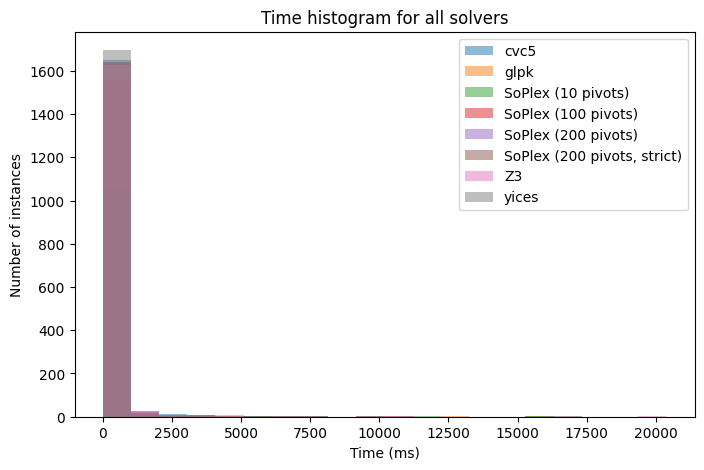

In [550]:
plot_time_histogram(*profile_results, title="Time histogram for all solvers", fixed_min_bin=0)

In [551]:
len(set(soplex_i100[soplex_i100["theory::arith::z::arith::relax::calls"] > 0].index)
    | set(soplex_i200[soplex_i200["theory::arith::z::arith::relax::calls"] > 0].index))

240

In [552]:
query_time(*profile_results, instances=("0028-labyrinth-12-0.smt2", "0075-labyrinth-13-0.smt2"))

,cvc5,glpk,SoPlex (10 pivots),SoPlex (100 pivots),SoPlex (200 pivots),"SoPlex (200 pivots, strict)",Z3,yices
0028-labyrinth-12-0.smt2,36.900,29.747,24.467,29.919,35.621,35.621,3.57,2.888
0075-labyrinth-13-0.smt2,122.582,106.315,36.765,107.315,119.387,119.387,8.40,321.847


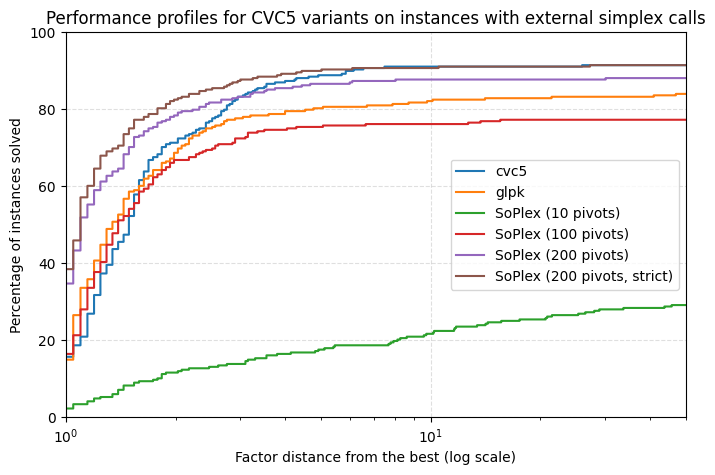

In [553]:
ax, fig = plot_performance_profiles(
    *external_cvc5_variants__results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=50,
    # metric_add=0.001,
    title="Performance profiles for CVC5 variants on instances with external simplex calls",
)
# Save the figure for latex paper
ax.get_figure().savefig("cvc5_external_simplex_calls.pdf", bbox_inches="tight")

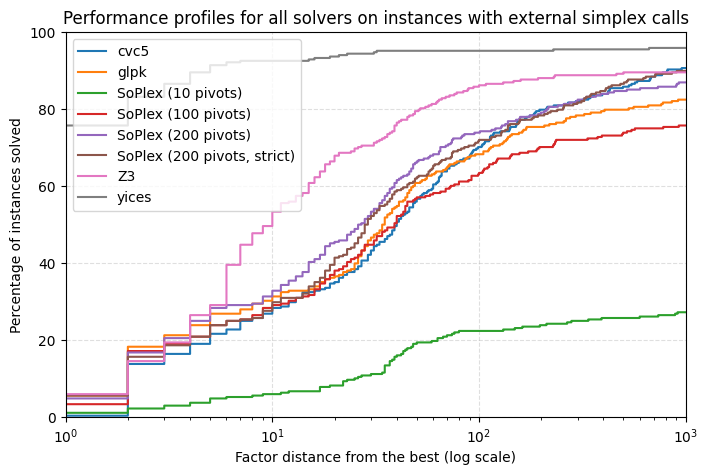

In [554]:
ax, fig = plot_performance_profiles(
    *external_profile_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
    metric_add=0.001,
    title="Performance profiles for all solvers on instances with external simplex calls",
)
ax.get_figure().savefig("all_external_simplex_calls.pdf", bbox_inches="tight")

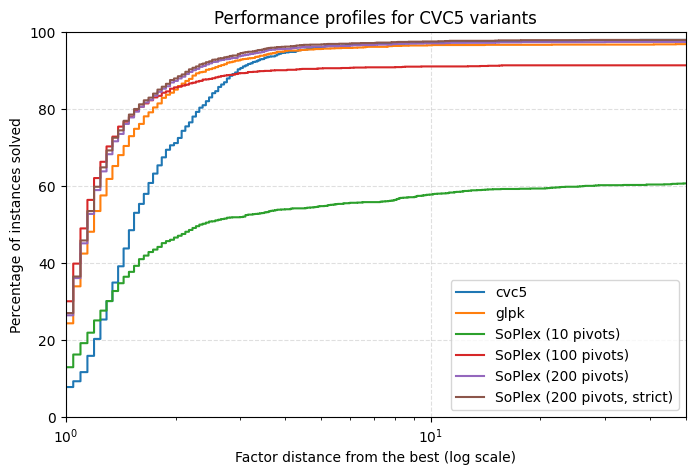

In [555]:
ax, fig = plot_performance_profiles(
    *cvc5_variants_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=50,
    metric_add=0.001,
    title="Performance profiles for CVC5 variants",
)

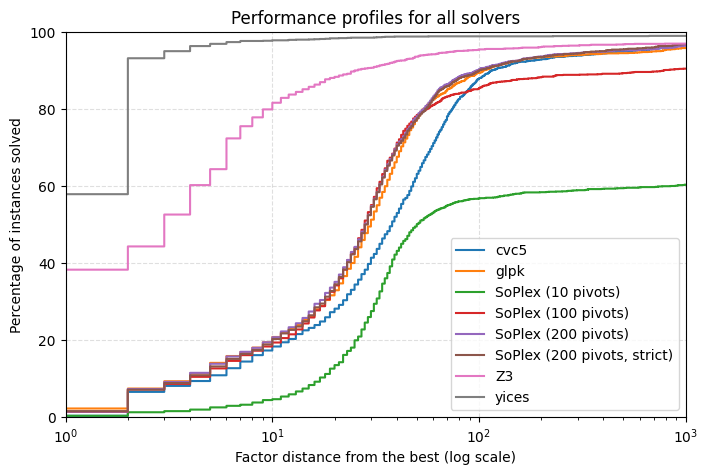

In [556]:
ax, fig = plot_performance_profiles(
    *profile_results,
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
    metric_add=0.001,
    title="Performance profiles for all solvers",
)